In [25]:
import pandas as pd
from scipy import stats
import numpy as np
from common.consts import groupByResidue, groupByProperty, mutation_map, proteins
from common.utils import estimateMFPT

short_to_residue = {short: idx for idx, shorts in groupByResidue.items() for short in shorts}
short_to_property = {short: prop for prop, shorts in groupByProperty.items() for short in shorts}

eigenvalue_data = pd.read_csv('../data/eigenvalues.csv', index_col='mutation')
full_evec_dot = pd.read_csv('../data/full_evec_dot.csv', index_col='Mutant')
avg_change_diff = pd.read_csv('../data/average_change_difference.csv', index_col='Mutant')
avg_change_folded = pd.read_csv('../data/average_change_folded.csv', index_col='Mutant')
avg_change_unfolded = pd.read_csv('../data/average_change_unfolded.csv', index_col='Mutant')
cov_dot_product = pd.read_csv('../data/cov_dot_products.csv', index_col='Mutant')
diagonal_cov_dot_products = pd.read_csv('../data/diagonal_cov_dot_products.csv', index_col='Mutant')
variance_differences = pd.read_csv('../data/variance_differences.csv', index_col='Mutant')
Tm = pd.read_csv('../data/Tm.csv', index_col='Mutant')

wt_Tm = Tm['Tm'].get('WT')

def collect_df(all_mfpt, th: float, sample_size: int):
    rows = []

    for long_name in proteins:
        short = mutation_map.get(long_name)
        if short is None:
            raise ValueError(f"Unknown mutation: {long_name}")
        s = np.sort(np.array(all_mfpt[long_name][th]))
        mfpt, lim = estimateMFPT(s)
        print(f"{long_name} ({short}): {(mfpt * 1e-6):.4g} us, extra: {lim:.4g}")

        rows.append({
            "long": long_name,
            "short": short,
            "eigenvalue": eigenvalue_data.loc[short, "eigenvalue"],
            "mfpt": mfpt,
            "lim": lim,
            "full_evec_dot": full_evec_dot['full_evec'].get(short, None),
            "cos_sim_folded": cov_dot_product['CosSim_Folded'].get(short, None),
            "cos_sim_unfolded": cov_dot_product['CosSim_Unfolded'].get(short, None),
            "avg_change_diff": avg_change_diff['AvgChange_Diff_F-U'].get(short, None),
            "diagonal_cov_dot_folded": diagonal_cov_dot_products['Diagonal_Dot_Folded'].get(short, None),
            "diagonal_cov_dot_unfolded": diagonal_cov_dot_products['Diagonal_Dot_Unfolded'].get(short, None),
            "abs_dvar_folded": variance_differences['abs_dvar_F'].get(short, None),
            "avg_change_folded": avg_change_folded['AvgChange_Folded'].get(short, None),
            "avg_change_unfolded": avg_change_unfolded['AvgChange_Unfolded'].get(short, None),
            "abs_dvar_unfolded": variance_differences['abs_dvar_U'].get(short, None),
            "residue_idx": short_to_residue.get(short),
            "property_grp": short_to_property.get(short),
            "tm": Tm['Tm'].get(short),
        })

    df = pd.DataFrame(rows)
    df.set_index("short", inplace=True)
    return df


0.18000000000000002
chignolin (WT): 0.3267 us, extra: 27
YYCPETGTWY (D2C): 6.844 us, extra: 11
YYDPETGTWE (Y9E): 0.06242 us, extra: 15
YYRPETGTWY (D2R): 1.975 us, extra: 35
YYAPETGTWY (D2A): 1.089 us, extra: 14
YYDPETGQWY (T7Q): 8.982 us, extra: 11
YYDPETGTWG (Y9G): 0.01831 us, extra: 10
YYDPETGTWQ (Y9Q): 0.1023 us, extra: 5
YYNPETGTWY (D2N): 0.5473 us, extra: 11
YYEPETGTWY (D2E): 2.34 us, extra: 15
YYDPETGTWR (Y9R): 0.3414 us, extra: 13
YYDPETGVWY (T7V): 1.86 us, extra: 23
YYDPETGYWY (T7Y): 0.8552 us, extra: 46
YYDPETGTWV (Y9V): 0.1636 us, extra: 51
YYDPETGRWY (T7R): 11.73 us, extra: 6


/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)
/rg/mendels_prj/alexander.z/protein-toolkit/src/common/utils.py:45: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  return float(1 / max.prediction), int(limit)


YYDPETGTWA (Y9A): 0.03151 us, extra: 55
YYDPETGGWY (T7G): 0.1885 us, extra: 23
YYMPETGTWY (D2M): 1.824 us, extra: 11
YYDPETGDWY (T7D): 1.882 us, extra: 22


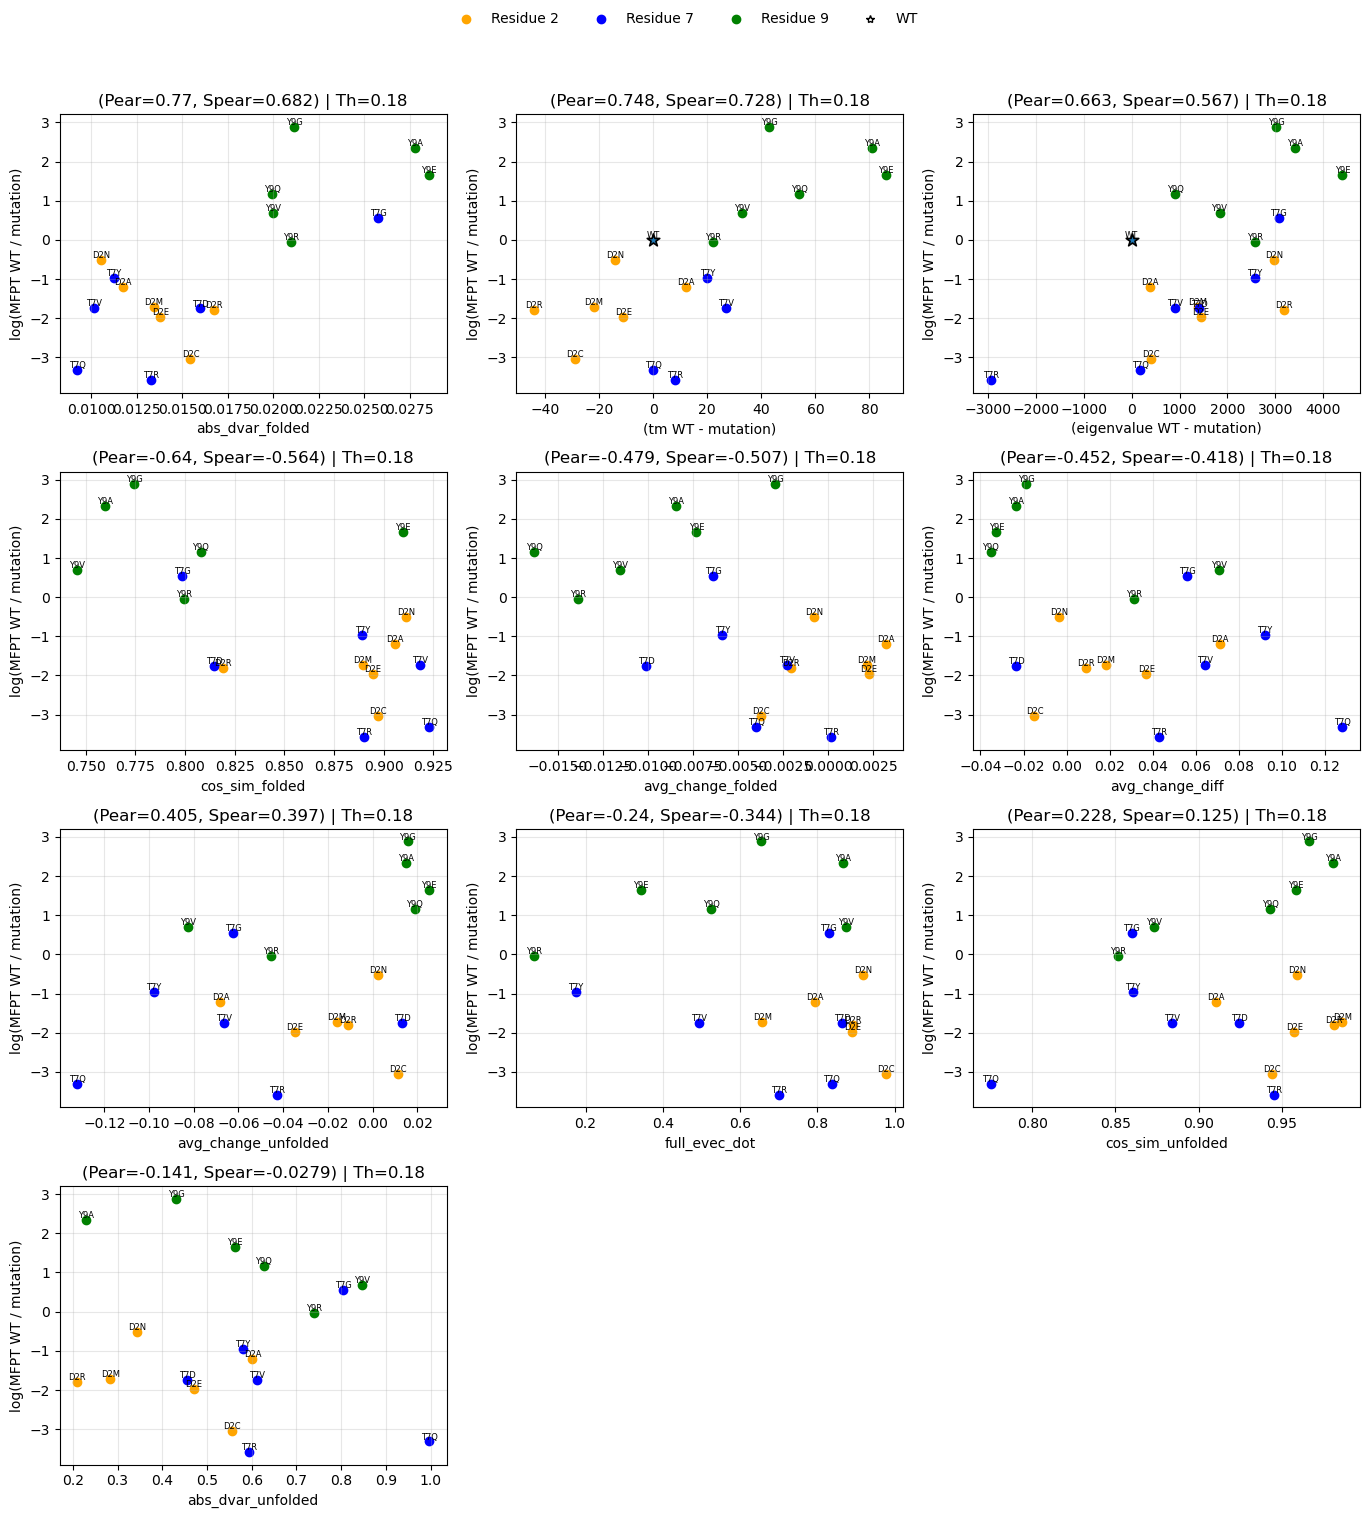

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
import pickle
from common.consts import res_colors

def ratio_or_raw(wt, arr, prop_name):
    if pd.isna(wt):
        return arr
    return wt - arr if prop_name != 'tm' else np.array(wt - arr) 

def plot_mfpt_corr_grid(
    df: pd.DataFrame,
    prop_cols,
    th=None,
    ncols=3
):
    wt_label = 'WT'
    group_col = 'residue_idx'
    res_keys = sorted(int(k) for k in df[group_col].dropna().unique())

    wt_mfpt = float(df.loc[wt_label, 'mfpt'])
    y_all = np.log(wt_mfpt / df['mfpt'].to_numpy())
    names = df.index.to_numpy()
    wt_star = dict(s=90, marker='*', edgecolors='k', linewidths=1.2, zorder=3)

    x_cache = {}
    mask_cache = {}
    corr = {}

    for prop_col in prop_cols:
        wt_prop = df.loc[wt_label, prop_col]
        x_all = ratio_or_raw(wt_prop, df[prop_col].to_numpy(), prop_col)
        mask = np.isfinite(x_all) & np.isfinite(y_all)
        x_cache[prop_col] = x_all
        mask_cache[prop_col] = mask

        pearson_r, _ = stats.pearsonr(x_all[mask], y_all[mask])
        spearman_r, _ = stats.spearmanr(x_all[mask], y_all[mask])
        corr[prop_col] = (pearson_r, spearman_r)

    ordered = sorted(prop_cols, key=lambda p: abs(corr[p][0]) if pd.notna(corr[p][0]) else -np.inf, reverse=True)
    n = len(ordered)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.8 * nrows), squeeze=False)

    for idx, prop_col in enumerate(ordered):
        ax = axes[idx // ncols][idx % ncols]
        x_all = x_cache[prop_col]
        mask = mask_cache[prop_col]
        wt_prop = df.loc[wt_label, prop_col]

        for k in res_keys:
            sel = (df[group_col].to_numpy() == k)
            ax.scatter(x_all[sel], y_all[sel], c=res_colors.get(k))

        if not pd.isna(wt_prop):
            ax.scatter(0, 0, **wt_star)

        for xv, yv, name, m in zip(x_all, y_all, names, mask):
            if m:
                ax.text(xv, yv, name, fontsize=6, ha='center', va='bottom')

        pearson_r, spearman_r = corr[prop_col]
        ax.set_xlabel((f'({prop_col} WT - mutation)' if not pd.isna(wt_prop) else prop_col))
        ax.set_ylabel('log(MFPT WT / mutation)')
        ax.set_title(f"(Pear={pearson_r:.3g}, Spear={spearman_r:.3g}) | Th={th:.3g}")
        ax.grid(True, alpha=0.3)

    for j in range(n, nrows * ncols):
        fig.delaxes(axes[j // ncols][j % ncols])

    handles = [Line2D([0], [0], marker='o', linestyle='', color=res_colors[k], label=f"Residue {k}") for k in res_keys]
    handles.append(Line2D([0], [0], marker='*', linestyle='', color='w', markeredgecolor='k', label=wt_label))
    fig.legend(handles=handles, loc='upper center', ncol=min(len(handles), 6), frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    return corr

props = [
    'cos_sim_unfolded','cos_sim_folded',
    'eigenvalue','full_evec_dot','avg_change_diff','avg_change_folded',
    'avg_change_unfolded',
    'abs_dvar_folded','abs_dvar_unfolded',
    'tm'
]
#'diagonal_cov_dot_folded',

with open("../data/mfpt-pace=25000.pkl", "rb") as f:
    all_mfpt = pickle.load(f)

sample_size = 200
thresholds = np.sort(np.array(list(all_mfpt['chignolin'].keys()), dtype=float))
th = thresholds[2]
print(th)
df = collect_df(all_mfpt, th, sample_size)
stats_map = plot_mfpt_corr_grid(df, props, th=th)


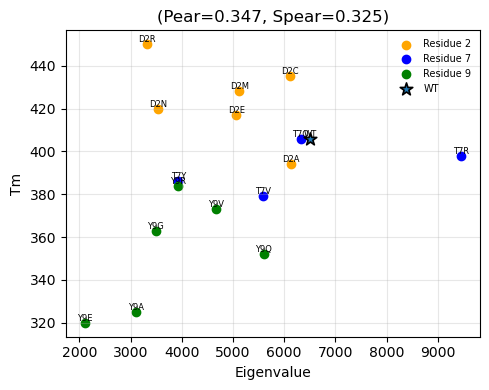

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from common.consts import res_colors

def plot_eigenvalue_vs_tm(df):
    wt_label = "WT"
    group_col = "residue_idx"

    x_all = df["eigenvalue"].to_numpy()
    y_all = df["tm"].to_numpy()
    names = df.index.to_numpy()
    mask = np.isfinite(x_all) & np.isfinite(y_all)

    pearson_r, _ = stats.pearsonr(x_all[mask], y_all[mask])
    spearman_r, _ = stats.spearmanr(x_all[mask], y_all[mask])

    fig, ax = plt.subplots(figsize=(5,4))
    for k in sorted(int(x) for x in df[group_col].dropna().unique()):
        sel = (df[group_col].to_numpy() == k)
        ax.scatter(x_all[sel], y_all[sel], c=res_colors.get(k), label=f"Residue {k}")

    # WT marker
    if wt_label in df.index:
        ax.scatter(df.loc[wt_label, "eigenvalue"], df.loc[wt_label, "tm"],
                   s=90, marker="*", edgecolors="k", linewidths=1.2,
                   zorder=3, label=wt_label)

    # mutation names
    for xv, yv, name, m in zip(x_all, y_all, names, mask):
        if m:
            ax.text(xv, yv, str(name), fontsize=6, ha="center", va="bottom")

    ax.set_xlabel("Eigenvalue")
    ax.set_ylabel("Tm")
    ax.set_title(f"(Pear={pearson_r:.3g}, Spear={spearman_r:.3g})")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, fontsize=7)

    plt.tight_layout()
    plt.show()
plot_eigenvalue_vs_tm(df)

In [28]:
blosum62 = {
    ("D", "A"): -2, ("A", "D"): -2,
    ("D", "C"): -3, ("C", "D"): -3,
    ("D", "M"): -3, ("M", "D"): -3,
    ("D", "N"):  1, ("N", "D"):  1,
    ("D", "R"): -2, ("R", "D"): -2,
    ("D", "E"):  2, ("E", "D"):  2,
    ("Y", "E"): -2, ("E", "Y"): -2,
    ("Y", "G"): -3, ("G", "Y"): -3,
    ("Y", "Q"): -1, ("Q", "Y"): -1,
    ("Y", "R"): -2, ("R", "Y"): -2,
    ("Y", "V"): -1, ("V", "Y"): -1,
    ("Y", "A"): -2, ("A", "Y"): -2,
    ("T", "V"):  0, ("V", "T"):  0,
    ("T", "Q"): -1, ("Q", "T"): -1,
    ("T", "R"): -1, ("R", "T"): -1,
    ("T", "Y"): -2, ("Y", "T"): -2,
    ("T", "G"): -2, ("G", "T"): -2,
    ("T", "D"): -1, ("D", "T"): -1,
}
grantham = {
    ("D", "A"): 126, ("A", "D"): 126,
    ("D", "C"): 154, ("C", "D"): 154,
    ("D", "M"): 160, ("M", "D"): 160,
    ("D", "N"):  23, ("N", "D"):  23,
    ("D", "R"):  96, ("R", "D"):  96,
    ("D", "E"):  45, ("E", "D"):  45,
    ("Y", "E"): 122, ("E", "Y"): 122,
    ("Y", "G"): 147, ("G", "Y"): 147,
    ("Y", "Q"): 143, ("Q", "Y"): 143,
    ("Y", "R"):  77, ("R", "Y"):  77,
    ("Y", "V"):  32, ("V", "Y"):  32,
    ("Y", "A"):  107, ("A", "Y"): 107,
    ("T", "V"):  69, ("V", "T"):  69,
    ("T", "Q"):  42, ("Q", "T"):  42,
    ("T", "R"):  71, ("R", "T"):  71,
    ("T", "Y"):  92, ("Y", "T"):  92,
    ("T", "G"):  59, ("G", "T"):  59,
    ("T", "D"):  65, ("D", "T"):  65,
}

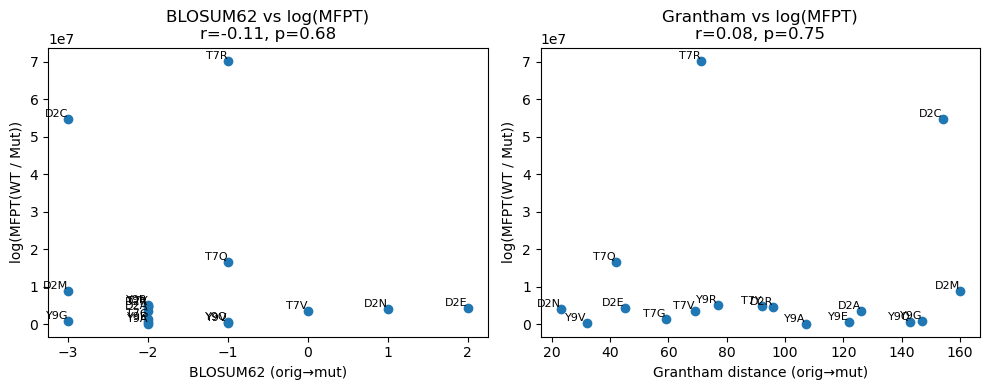

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def parse_short(s):
    return s[0], s[-1]

def compute_mfpt(long_name, th):
    s = np.sort(np.array(all_mfpt[long_name][th], float))
    mfpt, _ = estimateMFPT(s, 10)
    return float(mfpt)

def gather(proteins, mutation_map, th):
    xb, xg, y, labels = [], [], [], []
    wt_mfpt = compute_mfpt('chignolin', th)
    for long_name in proteins:
        short = mutation_map.get(long_name)
        if not short:
            continue
        a, b = parse_short(short)
        if (a, b) not in blosum62 or (a, b) not in grantham:
            continue
        mfpt = compute_mfpt(long_name, th)
        if not np.isfinite(mfpt) or mfpt <= 0:
            continue
        xb.append(float(blosum62[(a, b)]))
        xg.append(float(grantham[(a, b)]))
        y.append(mfpt)
        labels.append(short)
    return np.array(xb), np.array(xg), np.array(y), labels

def scatter_fit(ax, x, y, labels, title, xlabel):
    ax.scatter(x, y)
    for xi, yi, lab in zip(x, y, labels):
        ax.text(xi, yi, lab, fontsize=8, ha="right", va="bottom")

    if len(x) >= 2:
        r, p = stats.pearsonr(x, y)
        ax.set_title(f"{title}\nr={r:.2f}, p={p:.2g}")
    else:
        ax.set_title(title)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("log(MFPT(WT / Mut))")

def plot_correlations_over(proteins, mutation_map, th):
    xb, xg, y, labels = gather(proteins, mutation_map, th)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    scatter_fit(axes[0], xb, y, labels, "BLOSUM62 vs log(MFPT)", "BLOSUM62 (orig→mut)")
    scatter_fit(axes[1], xg, y, labels, "Grantham vs log(MFPT)", "Grantham distance (orig→mut)")
    plt.tight_layout()
    plt.show()
    return {"labels": labels, "blosum": xb, "grantham": xg, "log_mfpt": y}

# Example usage
th = thresholds[5]
res = plot_correlations_over(proteins[:-1], mutation_map, th)


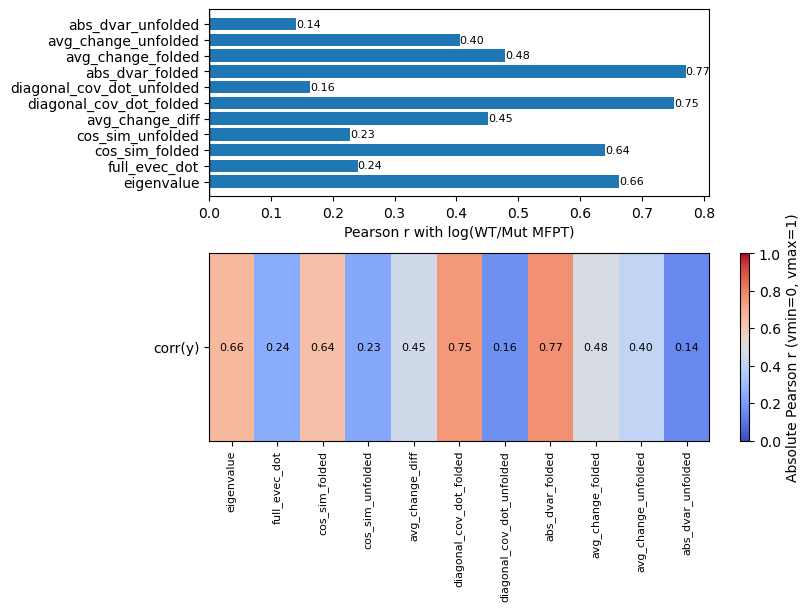

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def corr_vector(df, features, target_log_ratio=True):
    wt_mfpt = float(df.loc['WT','mfpt'])
    y = np.log(wt_mfpt / df['mfpt'].to_numpy()) if target_log_ratio else df['mfpt'].to_numpy()
    cors = []
    for f in features:
        x = df[f].to_numpy(dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() >= 3 and np.std(x[m]) > 1e-12 and np.std(y[m]) > 1e-12:
            r, _ = stats.pearsonr(x[m], y[m])
        else:
            r = np.nan
        cors.append(np.abs(r))
    return np.array(cors, float)

def plot_corr_bar_and_heatmap(df, features):
    cors = corr_vector(df, features, target_log_ratio=True)

    fig, axes = plt.subplots(2, 1, figsize=(max(8, 0.6*len(features)), 6), constrained_layout=True)

    ax = axes[0]
    ax.barh(features, np.nan_to_num(cors, nan=0.0))
    ax.axvline(0, lw=1, color='k')
    ax.set_xlabel("Pearson r with log(WT/Mut MFPT)")
    for i, r in enumerate(cors):
        if np.isfinite(r):
            ax.text(r, i, f"{r:.2f}", va='center', ha='left' if r>=0 else 'right', fontsize=8)

    ax = axes[1]
    H = np.nan_to_num(cors, nan=0.0)[None, :]
    im = ax.imshow(H, aspect='auto', vmin=0, vmax=1, cmap='coolwarm')
    ax.set_yticks([0])
    ax.set_yticklabels(["corr(y)"])
    ax.set_xticks(np.arange(len(features)))
    ax.set_xticklabels(features, rotation=90, fontsize=8)
    for j, r in enumerate(cors):
        txt = "NA" if not np.isfinite(r) else f"{r:.2f}"
        ax.text(j, 0, txt, ha='center', va='center', fontsize=8, color='black')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Absolute Pearson r (vmin=0, vmax=1)")

    plt.show()

# Example:
features = ["eigenvalue","full_evec_dot","cos_sim_folded","cos_sim_unfolded",
            "avg_change_diff","diagonal_cov_dot_folded","diagonal_cov_dot_unfolded",
            "abs_dvar_folded","avg_change_folded","avg_change_unfolded",
            "abs_dvar_unfolded"]
plot_corr_bar_and_heatmap(df, features)

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'eigenvalue': 'N', 'full_evec_dot': 'N', 'cos_sim_folded': 'N', 'cos_sim_unfolded': 'N', 'avg_change_diff': 'N', 'diagonal_cov_dot_unfolded': 'N', 'abs_dvar_folded': 'N', 'avg_change_folded': 'N', 'avg_change_unfolded': 'N', 'abs_dvar_unfolded': 'N', 'mfpt': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'eigenvalue': 'N', 'full_evec_dot': 'N', 'cos_sim_folded': 'N', 'cos_sim_unfolded': 'N', 'avg_change_diff': 'N', 'diagonal_cov_dot_unfolded': 'N', 'abs_dvar_folded': 'N', 'avg_change_folded': 'N', 'avg_change_unfolded': 'N', 'abs_dvar_unfolded': 'N', 'mfpt': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'eigenvalue': 'N', 'full_evec_dot': 'N', 'cos_sim_folded': 'N', 'cos_sim_unfolded': 'N', 'avg_change_diff': 'N', 'diagonal_cov_dot_unfolded': 'N', 'abs_dv

  0%|          | 0/1000000 [00:00<?, ?it/s]

/home/alexander.z/miniconda3/envs/gmx-plumed/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/alexander.z/miniconda3/envs/gmx-plumed/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/alexander.z/miniconda3/envs/gmx-plumed/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/alexander.z/miniconda3/envs/gmx-plumed/lib/python3.10/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarn

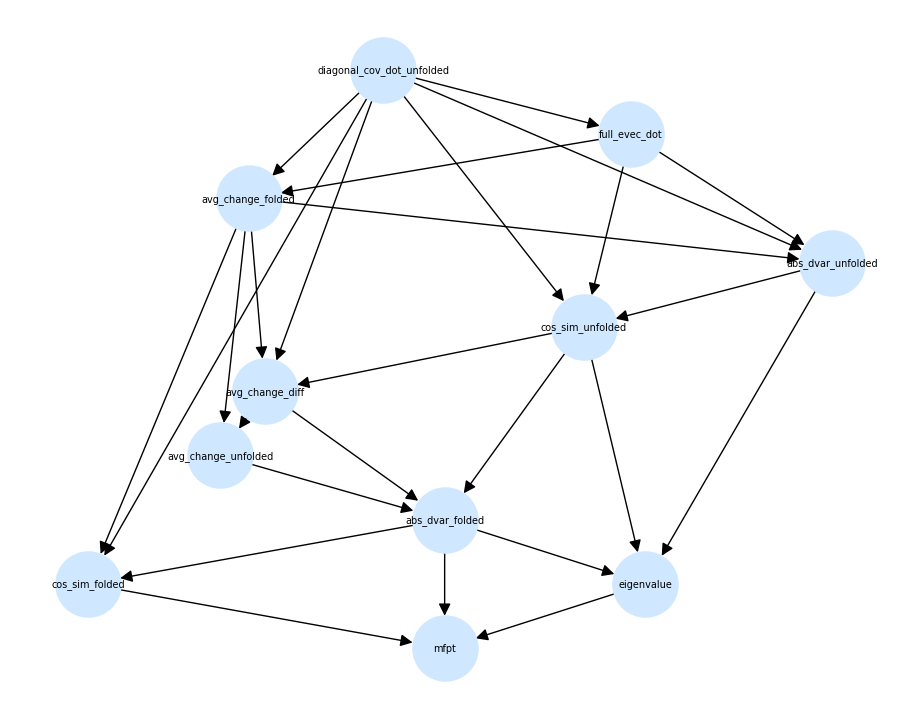

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import normalized_mutual_info_score
from pgmpy.estimators import HillClimbSearch, ExpertKnowledge, MaximumLikelihoodEstimator
from pgmpy.models import LinearGaussianBayesianNetwork
from networkx.drawing.nx_agraph import graphviz_layout

def _bin_series(s):
    n_bins = 3
    s = pd.Series(s).astype(float)

    return pd.qcut(s, q=n_bins, labels=[f"q{i+1}" for i in range(n_bins)], duplicates="drop")



def discretize_df(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = _bin_series(out[c])
    return out

def learn_discrete_bn(df, draw=True):
    # wt_mfpt = float(df.loc["Wildtype", "mfpt"])
    # dfb = df.copy()
    # if "Wildtype" in dfb.index:
    #     dfb = dfb.drop("Wildtype")

    features = [
        "eigenvalue","full_evec_dot","cos_sim_folded","cos_sim_unfolded",
        "avg_change_diff","diagonal_cov_dot_unfolded",
        "abs_dvar_folded","avg_change_folded","avg_change_unfolded",
        "abs_dvar_unfolded", "mfpt"
    ]
    df = df[features].dropna()
    df['mfpt'] = df['mfpt'].astype(float) * 1e-6  
    nodes = list(df.columns)

    ek = ExpertKnowledge(
        forbidden_edges=[("mfpt", v) for v in nodes if v != "mfpt"]
    )

    est = HillClimbSearch(df)
    best = est.estimate(scoring_method="ll-g", expert_knowledge=ek, max_indegree=3)
    model = LinearGaussianBayesianNetwork(best.edges())
    model.fit(df)

    G = nx.DiGraph(model.edges())
    plt.figure(figsize=(9, 7))

    from networkx.drawing.nx_agraph import graphviz_layout
    pos = graphviz_layout(G, prog="dot")

    nx.draw(
        G, pos,
        with_labels=True,
        node_color="#cfe8ff",
        node_size=2200,
        font_size=7,
        arrowsize=18
    )
    plt.tight_layout()
    plt.show()
  
 

    return model

bn_model = learn_discrete_bn(df, draw=True)


In [32]:
from sklearn.feature_selection import mutual_info_regression

features = [
        "eigenvalue","full_evec_dot","cos_sim_folded","cos_sim_unfolded",
        "avg_change_diff","diagonal_cov_dot_unfolded",
        "abs_dvar_folded","avg_change_folded","avg_change_unfolded",
        "abs_dvar_unfolded"
    ]
X = df[features].to_numpy()
y = df["mfpt"].to_numpy()

mi = mutual_info_regression(X, y, random_state=0)

# pair variable names with MI values
mi_scores = dict(zip(features, mi))
print(mi_scores)

ValueError: Input X contains NaN.

/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
/tmp/ipykernel_2805851/60863814.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(path, delim_whitespace=True, commen

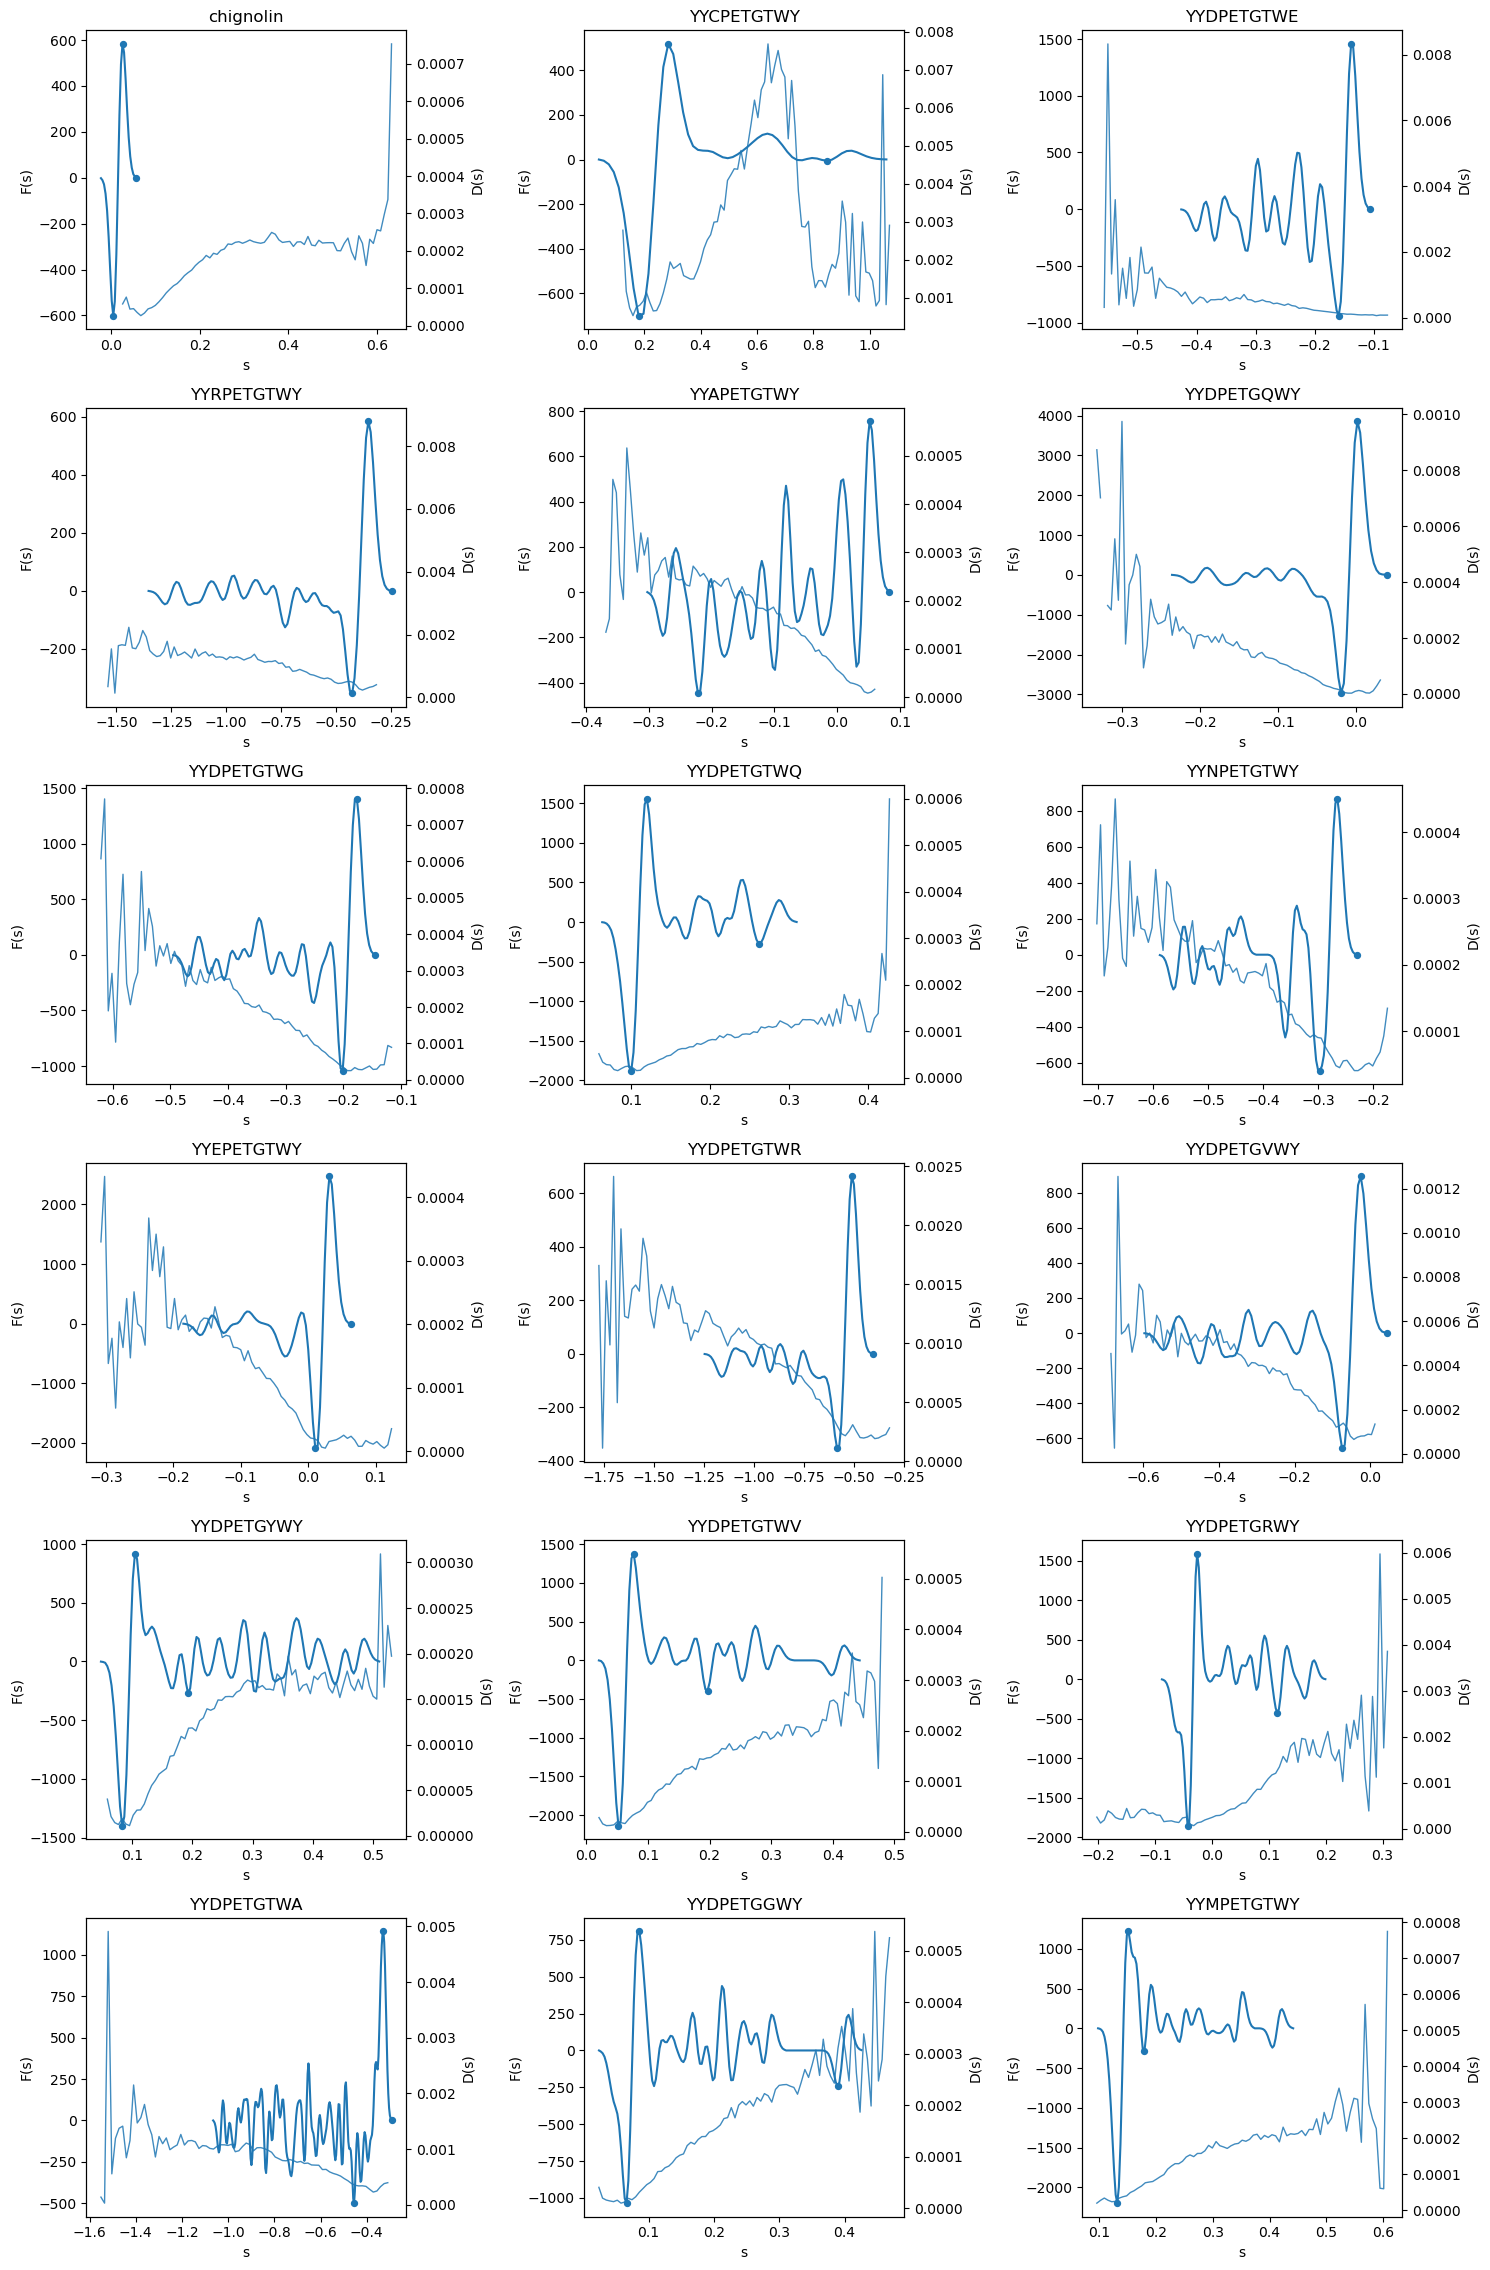

In [ ]:
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common.consts import proteins

cv_col = "HLDA"
runs = range(4000, 4050)
bins_diff = 80
lag = 1

def sum_hills(hills, out):
    out.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["plumed","sum_hills","--hills",str(hills),"--mintozero","--outfile",str(out)], check=True, stdout=subprocess.DEVNULL)

def read_fes(path):
    df = pd.read_csv(path, delim_whitespace=True, comment="#", header=None)
    if df.shape[1] == 2:
        df.columns = ["s","F"]
    else:
        df.columns = [f"c{i}" for i in range(df.shape[1])]
        df = df.rename(columns={df.columns[0]:"s", df.columns[-1]:"F"})[["s","F"]]
    return df.sort_values("s").reset_index(drop=True)

def read_colvar_with_fields(path):
    with open(path, "r") as f:
        header = f.readline().strip()
    names = header.split()[2:]
    return pd.read_csv(path, sep=r"\s+", comment="#", names=names, engine="python")

def get_cv_column(df):
    if cv_col in df.columns: return cv_col
    low = {c.lower(): c for c in df.columns}
    return low[cv_col.lower()]

def estimate_D_of_s(colvar_paths, nbins=bins_diff, lag=lag):
    edges = None
    num = None
    cnt = None
    for p in colvar_paths:
        df = read_colvar_with_fields(p)
        cvc = get_cv_column(df)
        s = df[cvc].to_numpy()
        t = df["time"].to_numpy()
        if edges is None:
            edges = np.linspace(np.min(s), np.max(s), nbins + 1)
            num = np.zeros(nbins, dtype=float)
            cnt = np.zeros(nbins, dtype=int)
        else:
            smin = min(edges[0], np.min(s))
            smax = max(edges[-1], np.max(s))
            edges = np.linspace(smin, smax, nbins + 1)
        idx = np.digitize(s, edges) - 1
        ds = s[lag:] - s[:-lag]
        dt_local = t[lag:] - t[:-lag]
        vals = (ds * ds) / (2.0 * dt_local)
        idx0 = idx[:-lag]
        for k in range(nbins):
            m = (idx0 == k)
            if m.any():
                num[k] += np.sum(vals[m])
                cnt[k] += int(m.sum())
    centers = 0.5 * (edges[:-1] + edges[1:])
    D = np.full(nbins, np.nan)
    ok = cnt > 0
    D[ok] = num[ok] / cnt[ok]
    return centers, D, cnt

def left_min_max_right(fes):
    F = fes["F"].to_numpy(); s = fes["s"].to_numpy()
    imax = int(np.argmax(F))
    ileft = int(np.argmin(F[:imax])) if imax > 0 else 0
    iright = int(np.argmin(F[imax+1:]) + imax + 1) if imax < len(F) - 1 else len(F) - 1
    return (s[ileft], F[ileft]), (s[imax], F[imax]), (s[iright], F[iright])

def analyze_protein(p, runs):
    base = Path("../data") / p / "output"
    rep = runs.start
    rdir = base / f"run_{rep}"
    hills = rdir / f"HILLS_HLDA_{rep}"
    fes_path = rdir / f"fes_HLDA_{rep}.dat"
    sum_hills(hills, fes_path)
    fes = read_fes(fes_path)
    a, m, b = left_min_max_right(fes)
    colvars = [base / f"run_{i}" / f"HLDA_COLVAR_{i}" for i in runs]
    sgrid, D, N = estimate_D_of_s(colvars)
    return dict(p=p, fes=fes, a=a, m=m, b=b, sgrid=sgrid, D=D, N=N)

def plot_grid(per_row=3):
    results = [analyze_protein(p, runs) for p in proteins]
    n = len(results)
    rows = (n + per_row - 1) // per_row
    fig, axes = plt.subplots(rows, per_row, figsize=(per_row * 5.0, rows * 3.8), squeeze=False)
    for ax in axes.ravel(): ax.axis("off")
    for ax, r in zip(axes.ravel(), results):
        ax.axis("on")
        fes = r["fes"]; a, m, b = r["a"], r["m"], r["b"]
        ax.plot(fes["s"], fes["F"], lw=1.5)
        ax.scatter([a[0], m[0], b[0]], [a[1], m[1], b[1]], s=18)
        ax.set_xlabel("s"); ax.set_ylabel("F(s)")
        ax2 = ax.twinx()
        ax2.plot(r["sgrid"], r["D"], lw=1.0, alpha=0.85)
        ax2.set_ylabel("D(s)")
        ax.set_title(f"{r['p']}")
    plt.tight_layout()
    plt.show()

plot_grid(per_row=3)
